# Diabetes Risk Prediction

## 1) Problem Statement
* This project aims to understand how and individuals risk level is affected by factors such as high blood pressure, high cholestorol, BMI, etc.

## 2) Data Collection
* Dataset Source - [https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)
* The data consists of 22 columns and 253,680 rows

## 2.1 Import Data and Required Packages

### Importing Pandas, Numpy, MatPlotLib, Seaborn, annd Warnings libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import the CSV Data as Pandas DataFrame

In [2]:
df= pd.read_csv('data/diabetes_012_health_indicators_BRFSS2015.csv')

### Show top 5 records

In [3]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Shape of the dataset

In [4]:
df.shape

(253680, 22)

## 2.2 Dataset Information

| Variable Name | Type | Description | Key |
|---------------|------|-------------|-----|
| Diabetes_012 | Integer | Presence of Diabetes or Prediabetes (target) | 0 = no diabetes, 1 = prediabetes, 2 = diabetes |
| HighBP | Binary | Does the patient have high blood pressure | 0 = no high BP, 1 = high BP |
| HighChol | Binary | Does the patient have high cholesterol | 0 = no high cholesterol, 1 = high cholesterol |
| CholCheck | Binary | Has the patient had a cholesterol check in the past 5 years | 0 = no, 1 = yes |
| BMI | Integer | Body Mass Index ||
| Smoker | Binary | Has the patient smoked at least 100 cigarettes in their life (5 packs = 100 cigarettes) | 0 = no, 1 = yes |
| Stroke | Binary | Has the patient ever had a stroke | 0 = no, 1 = yes |
| HeartDiseaseorAttack | Binary | Does the patient have coronary heart disease (CHD) or have they experienced myocardial infarction (MI) | 0 = no, 1 = yes |
| PhysActivity | Binary | Has the patient had any physical activity in the past 30 days - not including their job | 0 = no, 1 = yes |
| Fruits | Binary | Does the patient consume fruit one or more times a day | 0 = no, 1 = yes |
| Veggies | Binary | Does the patient consume vegetables one or more times a day | 0 = no, 1 = yes |
| HvyAlcoholConsump | Binary | Is the patient a heavy drinker (>14 drinks per week for adult men and >7 drinks per week for adult women) | 0 = no, 1 = yes |
| AnyHealthcare | Binary | Does the patient have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. | 0 = no, 1 = yes |
| NoDocbcCost | Binary | Was there a time in the past 12 months when the patient needed to see a doctor but could not because of cost | 0 = no, 1 = yes |
| GenHlth | Integer | Patient's general health rating on a scale of 1-5 | 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor |
| MentHlth | Integer | The number of days the patient experienced symptoms of stress, depression, and emotional problems in the past 30 days ||
| PhysHlth | Integer | The number of days the patient experienced illness or injury in the past 30 days ||
| DiffWalk | Binary | Does the patient have serious difficulty walking or climbing stairs | 0 = no, 1 = yes |
| Sex | Binary | Patient's sex | 0 = female, 1 = male |
| Age | Integer | Patient's 13-level age category (See _AGEG5YR in [CDC BRFSS Calculated Variables Codebook](https://www.cdc.gov/brfss/annual_data/2020/pdf/2020-calculated-variables-version4-508.pdf)) | 1 = 18-24, 2 = 25-29, 3 = 30-34, 4 = 35-39, 5 = 40-44, 6 = 45-49, 7 = 50-54, 8 = 55-59, 9 = 60-64, 10 = 65-69, 11 = 70-74, 12 = 75-79, 13 = >80 |
| Education | Integer | Patient's education level (Converted from EDUCA to _EDUCAG, seen in [CDC BRFSS Calculated Variables Codebook](https://www.cdc.gov/brfss/annual_data/2020/pdf/2020-calculated-variables-version4-508.pdf)) | 1 = Did not graduate high school (EDUCA=1,2,3), 2 = graduated high school (EDUCA=4), 3 = attended college or technical school (EDUCA=5), 4 = graduated from college or technical school (EDUCA=6) |
| Income | Integer | Patient's income level (Converted from  INCOME2 to _INCOMG, seen in [CDC BRFSS Calculated Variables Codebook](https://www.cdc.gov/brfss/annual_data/2020/pdf/2020-calculated-variables-version4-508.pdf)) | 1 = <$15,000 (INCOME2=1,2), 2 = $15,000-$25,000 (INCOME2=3,4), 3 = $25,000-$35,000 (INCOME2=5), 4 = $35,000-$50,000 (INCOME2=6), 5 = >$50,000 (INCOME2=7,8) |

### Converting EDUCA to _EDUCAG and INCOME2 to _INCOMG

In [5]:
def EDUCAtoEDUCAG(category):
    if category in [1, 2, 3]:
        return 1
    elif category == 4:
        return 2
    elif category == 5:
        return 3
    else:
        return 4
    
def INCOME2toINCOMG(category):
    if category in [1, 2]:
        return 1
    elif category in [3, 4]:
        return 2
    elif category == 5:
        return 3
    elif category == 6:
        return 4
    else:
        return 5

In [6]:
df['Education'] = df['Education'].apply(EDUCAtoEDUCAG)
df['Income'] = df['Income'].apply(INCOME2toINCOMG)

## 3. Data Checks to Perform

* Check missing values
* Check duplicates
* Check data type
* Check the number of unique values in each column
* Check statistics of dataset
* Check various categories present in the different categorical columns

### 3.1 Check Missing Values

In [7]:
df.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### There are no missing values in the dataset

### 3.2 Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(29335)

### There are duplicates, so we will remove them

In [9]:
df = df.drop_duplicates()

### 3.3 Check Data Types

In [10]:
# Check null and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 224345 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          224345 non-null  float64
 1   HighBP                224345 non-null  float64
 2   HighChol              224345 non-null  float64
 3   CholCheck             224345 non-null  float64
 4   BMI                   224345 non-null  float64
 5   Smoker                224345 non-null  float64
 6   Stroke                224345 non-null  float64
 7   HeartDiseaseorAttack  224345 non-null  float64
 8   PhysActivity          224345 non-null  float64
 9   Fruits                224345 non-null  float64
 10  Veggies               224345 non-null  float64
 11  HvyAlcoholConsump     224345 non-null  float64
 12  AnyHealthcare         224345 non-null  float64
 13  NoDocbcCost           224345 non-null  float64
 14  GenHlth               224345 non-null  float64
 15  MentH

### 3.4 Checking the Number of Unique Values in Each Column

In [11]:
df.nunique()

Diabetes_012             3
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                4
Income                   5
dtype: int64

### 3.5 Check Statistics of Dataset

In [12]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,...,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000,224345.000000
mean,0.332354,0.458820,0.444521,0.958943,28.745874,0.468867,0.045813,0.105293,0.727981,0.608844,...,0.944795,0.094992,2.619247,3.585830,4.784283,0.189899,0.438668,8.091261,2.987368,3.757378
std,0.730507,0.498302,0.496914,0.198423,6.832676,0.499031,0.209081,0.306932,0.445000,0.488010,...,0.228381,0.293205,1.065735,7.786669,9.125031,0.392222,0.496225,3.099258,0.944300,1.424594
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2.000000,2.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,3.000000,4.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,4.000000,5.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,4.000000,5.000000


### 3.6 Exploring Data

In [13]:
# Define categorical and numerical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# Print columns
print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("\nWe have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 22 numerical features: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

We have 0 categorical features: []


### 3.7 Feature Engineering

In [14]:
# BMI Categories
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal weight"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obese"
    
df['BMICategory'] = df['BMI'].apply(bmi_category)

# BMI Age interaction
df["BMI_Age"] = df["BMI"] * df["Age"]

# High risk group, Obese and over 65 (Age group 10)
df["HighRiskObeseSenior"] = ((df["BMICategory"] == "Obese") & (df["Age"] >= 10)).astype(int)

### 4. Visual Data Exploration
#### 4.1 Univariate Analysis

In [15]:
# Define categorical and numerical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# Print columns
print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("\nWe have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 24 numerical features: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_Age', 'HighRiskObeseSenior']

We have 1 categorical features: ['BMICategory']


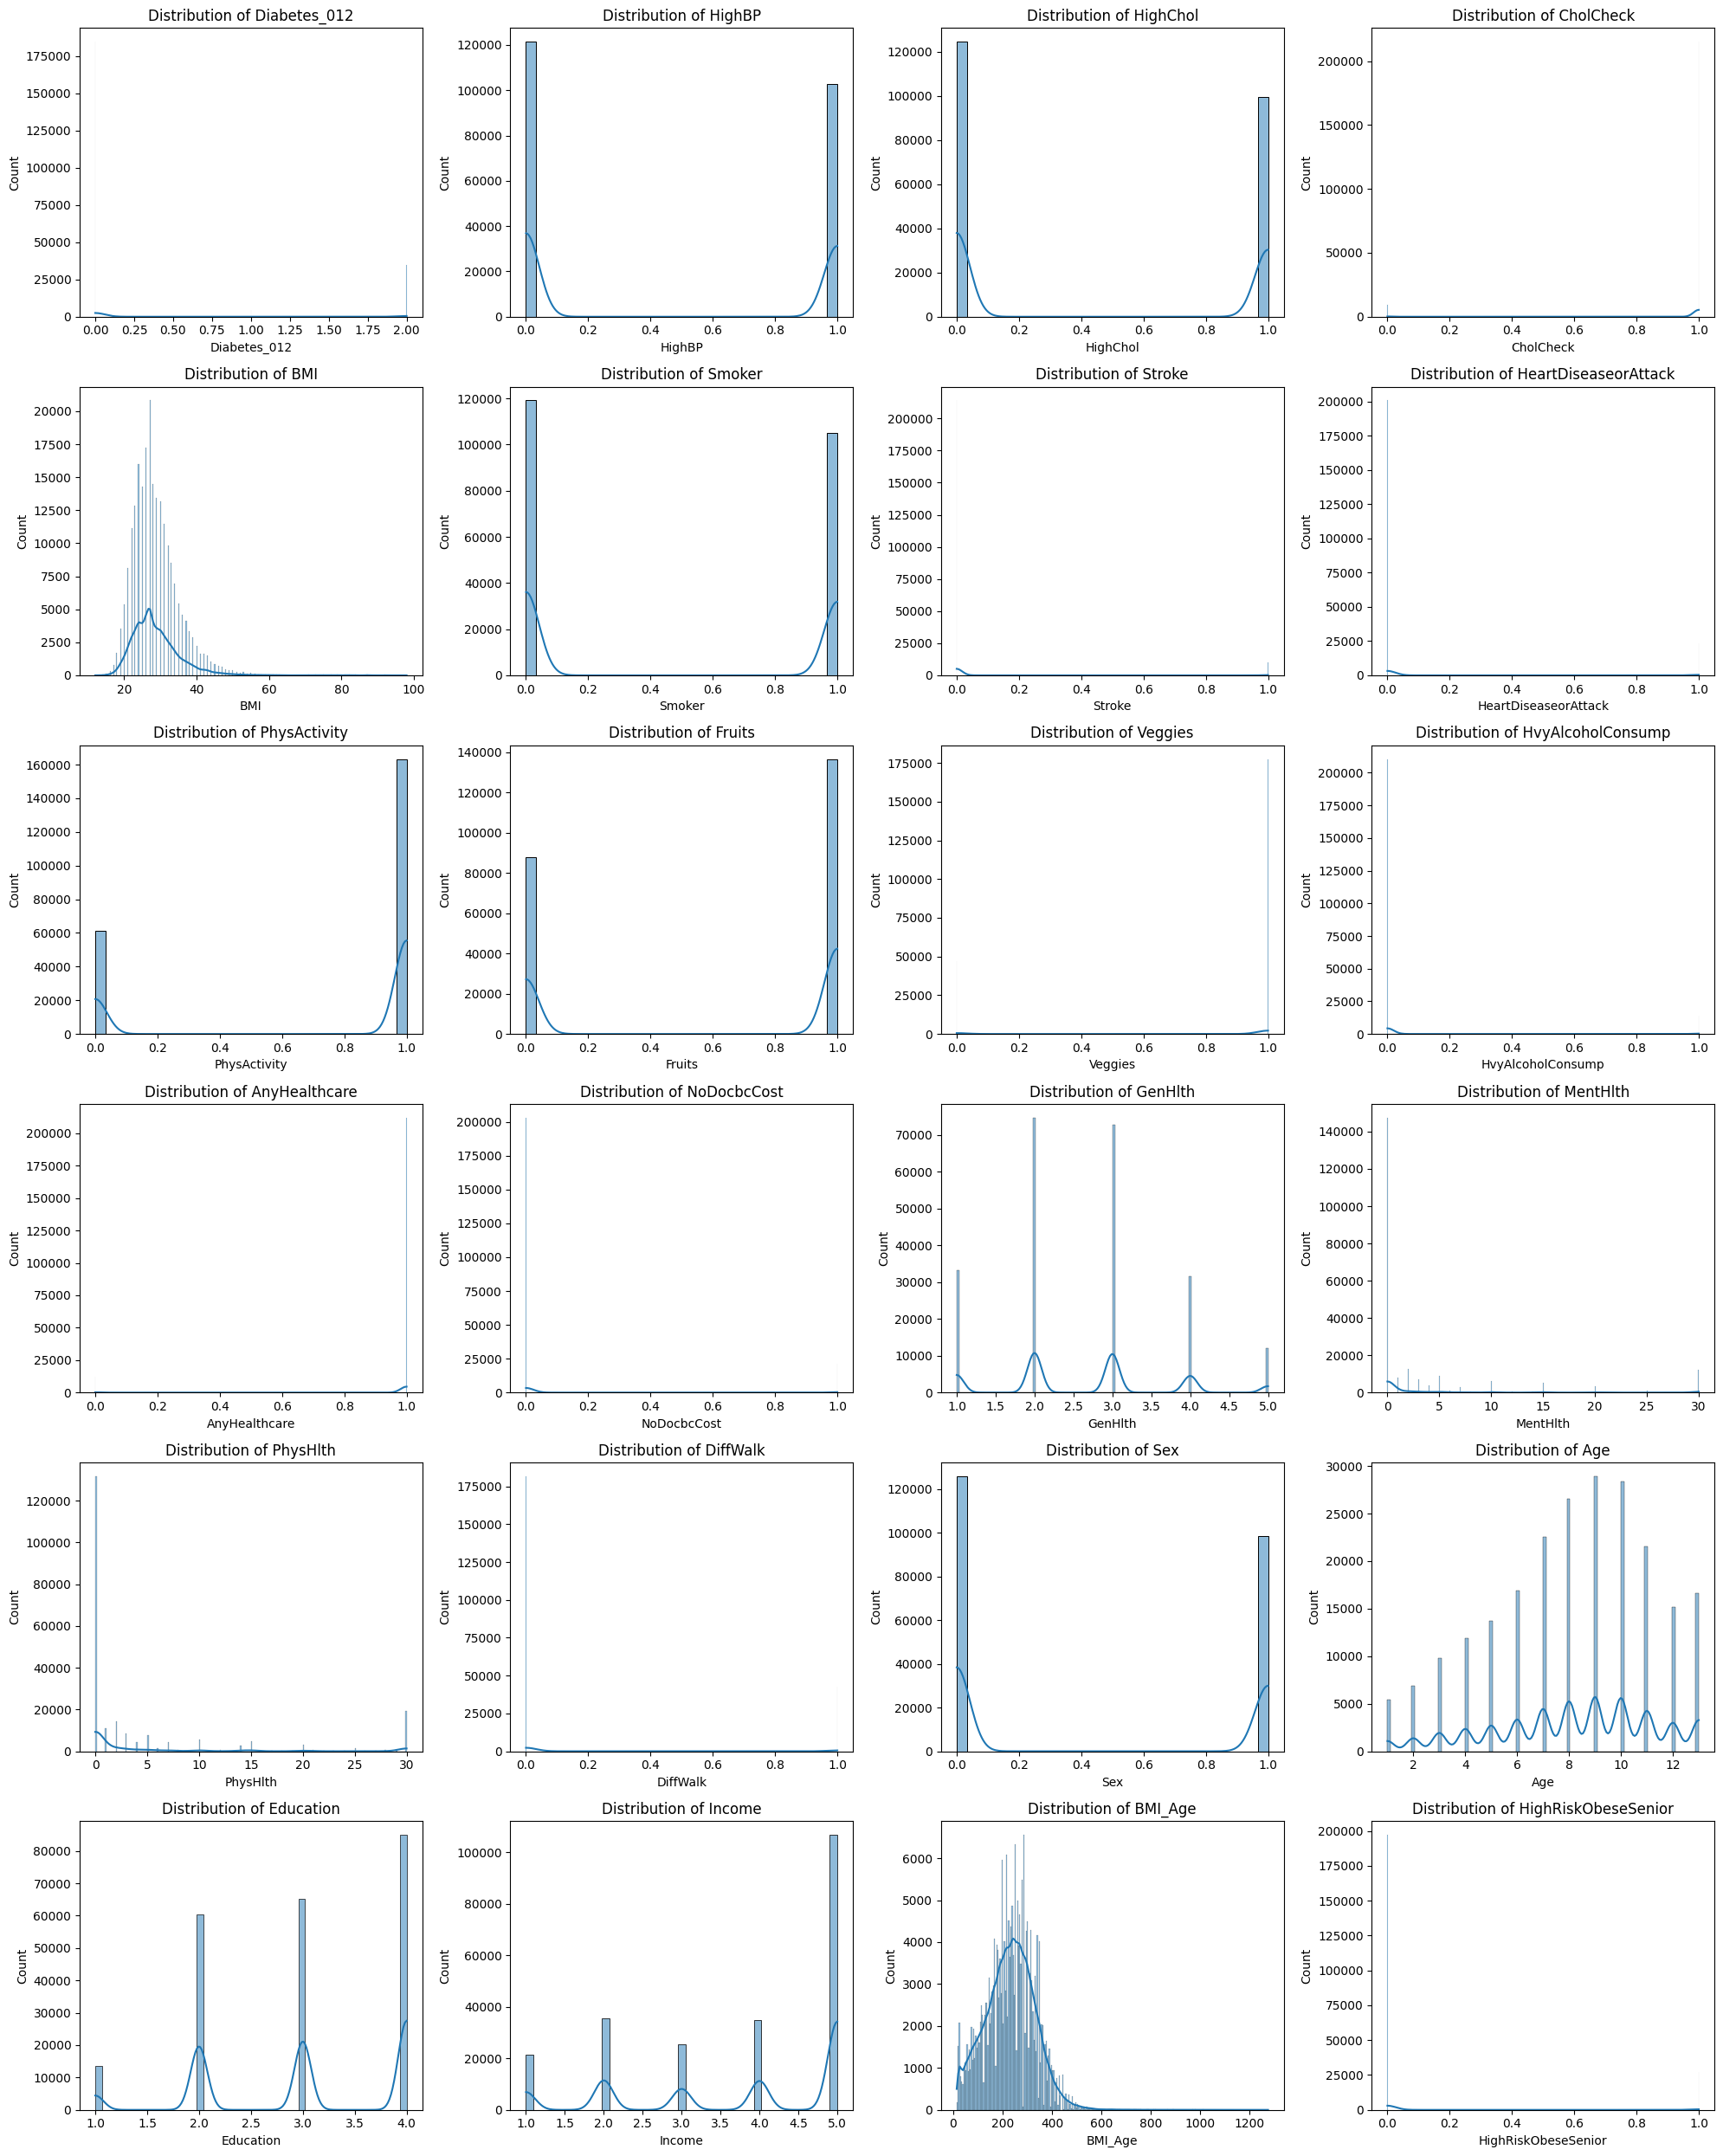

In [16]:
# Histograms of all numerical features
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 25))

for i, feature in enumerate(numeric_features):
    row = i // 4
    col = i % 4
    sns.histplot(data=df[feature], ax=axes[row, col], kde=True)
    axes[row, col].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

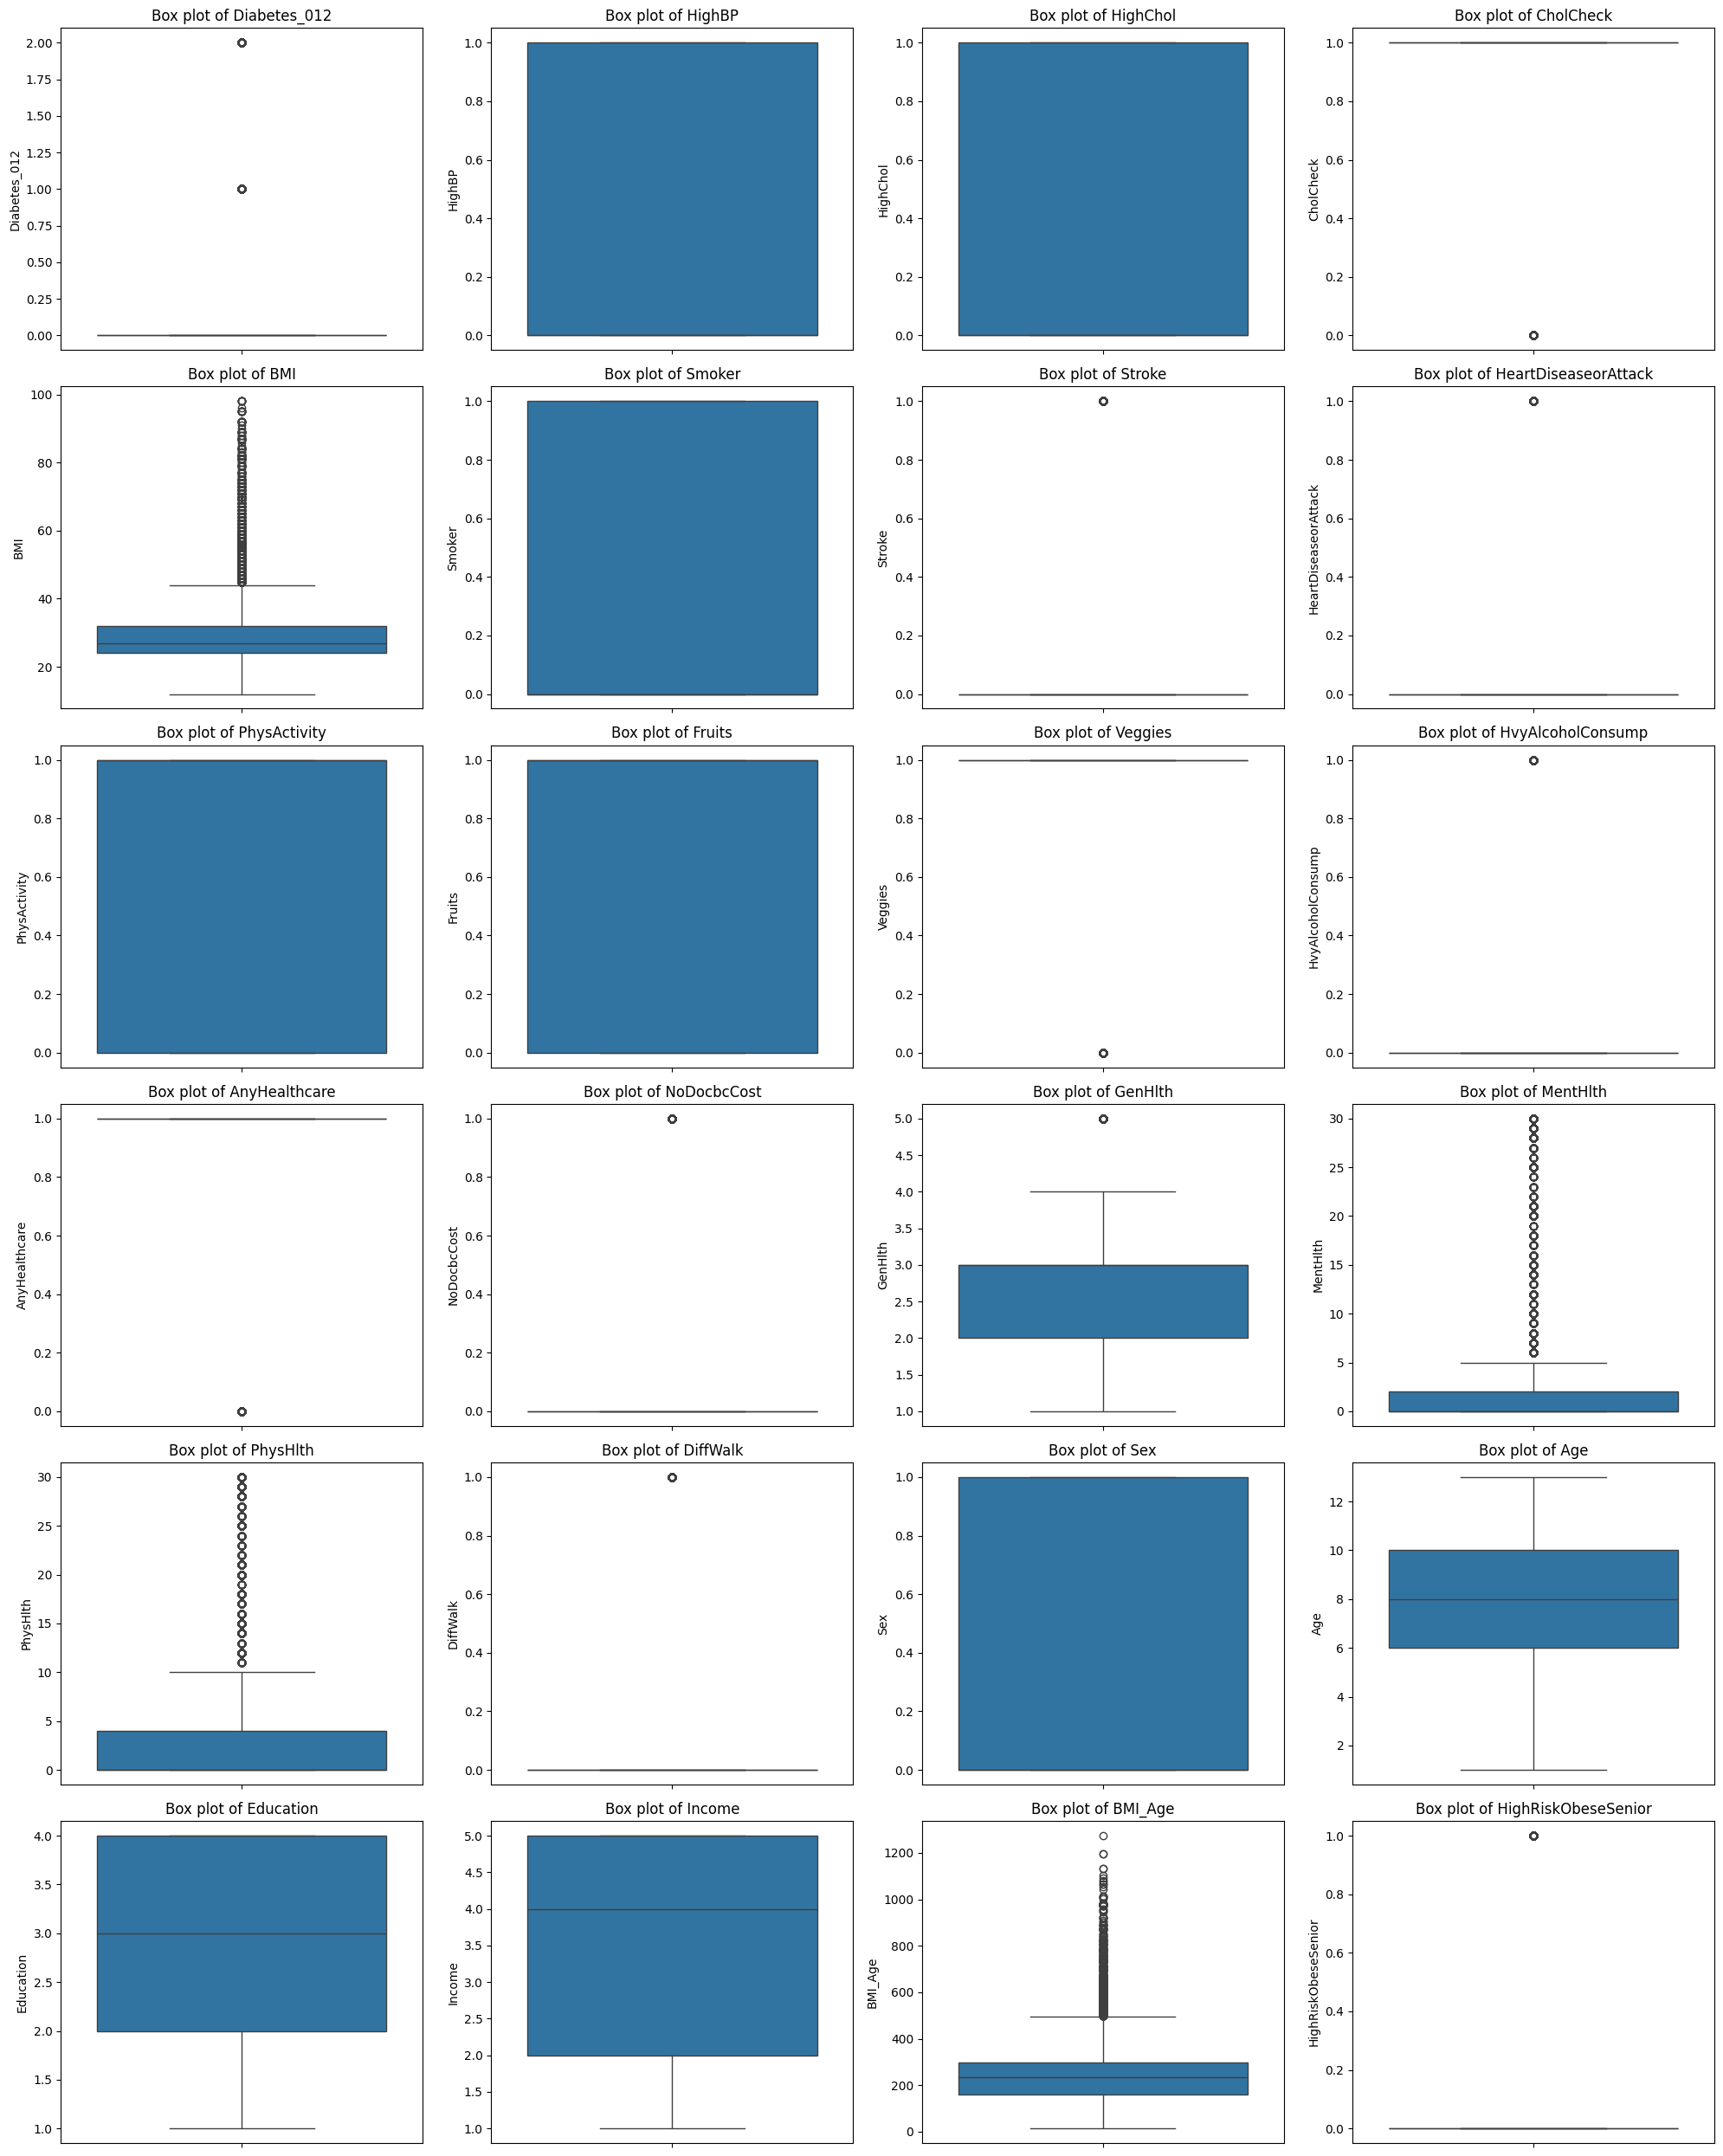

In [17]:
# Box plots of all numerical features
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 25))

for i, feature in enumerate(numeric_features):
    row = i // 4
    col = i % 4
    sns.boxplot(data=df[feature], ax=axes[row, col])
    axes[row, col].set_title(f"Box plot of {feature}")

plt.tight_layout()
plt.show()

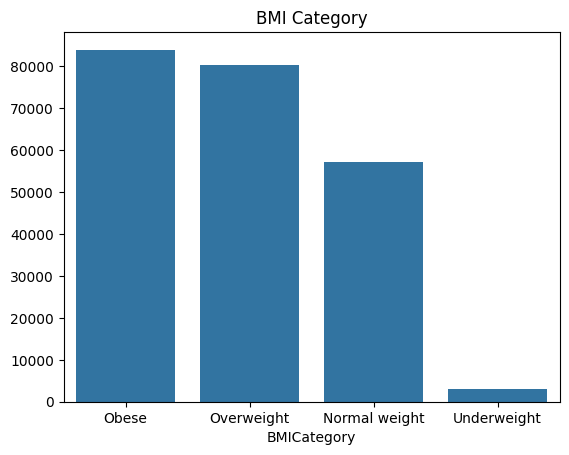

In [18]:
# Bar plot for categorical column
sns.barplot(x=df["BMICategory"].value_counts().index, y=df["BMICategory"].value_counts().values)
plt.title("BMI Category")

plt.show()

#### Insights:
* Most patients rate their general health between a 2 and a 3
* The average patient's BMI is between 20 and 40
* The age of most of the patients in the dataset is between 60 and 69
* Most patients classify as overweight or obese

#### Outlier Analysis

In [19]:
# Outlier detection using IQR

outlier_cols = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "BMI_Age"]

for col in outlier_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = [x for x in df[col] if x < lower_bound or x > upper_bound]
    print(f"Total outliers in {col}: {len(outliers)}")
    unique_outliers = set(outliers)
    print(f"Unique outliers in {col}: {unique_outliers}\n")

Total outliers in BMI: 5637
Unique outliers in BMI: {45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 95.0, 96.0, 98.0}

Total outliers in GenHlth: 12076
Unique outliers in GenHlth: {5.0}

Total outliers in MentHlth: 36137
Unique outliers in MentHlth: {6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0}

Total outliers in PhysHlth: 34334
Unique outliers in PhysHlth: {11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0}

Total outliers in BMI_Age: 1421
Unique outliers in BMI_Age: {512.0, 513.0, 516.0, 517.0, 518.0, 520.0, 522.0, 525.0, 528.0, 530.0, 531.0, 1044.0, 533.0, 534.0, 536.0, 539.0, 54

#### Insights:
* None of the outliers are errors, so we will leave them for now

#### Bivariate Analysis

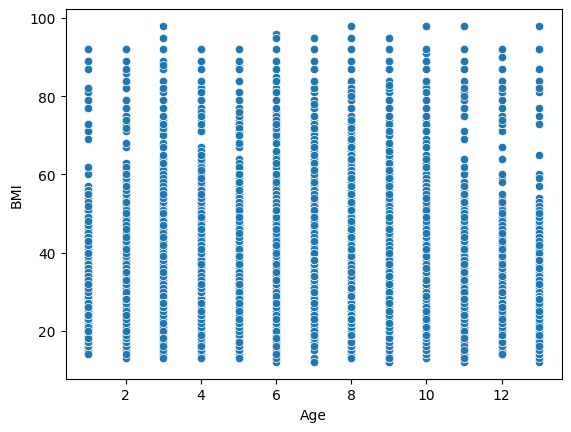

In [20]:
# Comparing Age and BMI
sns.scatterplot(x=df["Age"], y=df["BMI"])
plt.show()

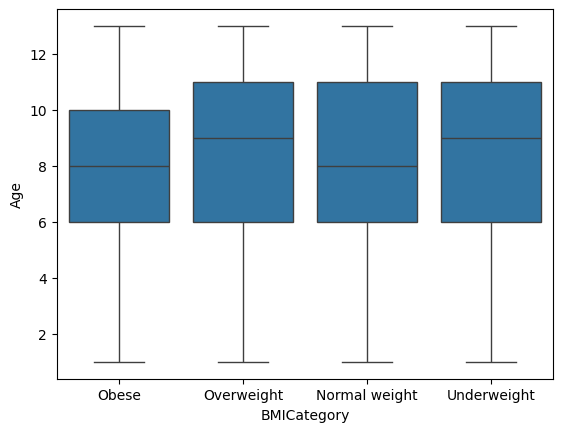

In [21]:
# Comparing Age to BMI Category
sns.boxplot(x=df["BMICategory"], y=df["Age"])
plt.show()

#### Insights:
* There does not appear to be a correlation between Age and BMI

In [22]:
# Convert BMICategory to dummy variables
df_dummies = pd.get_dummies(df, columns=["BMICategory"], prefix=["BMI"])

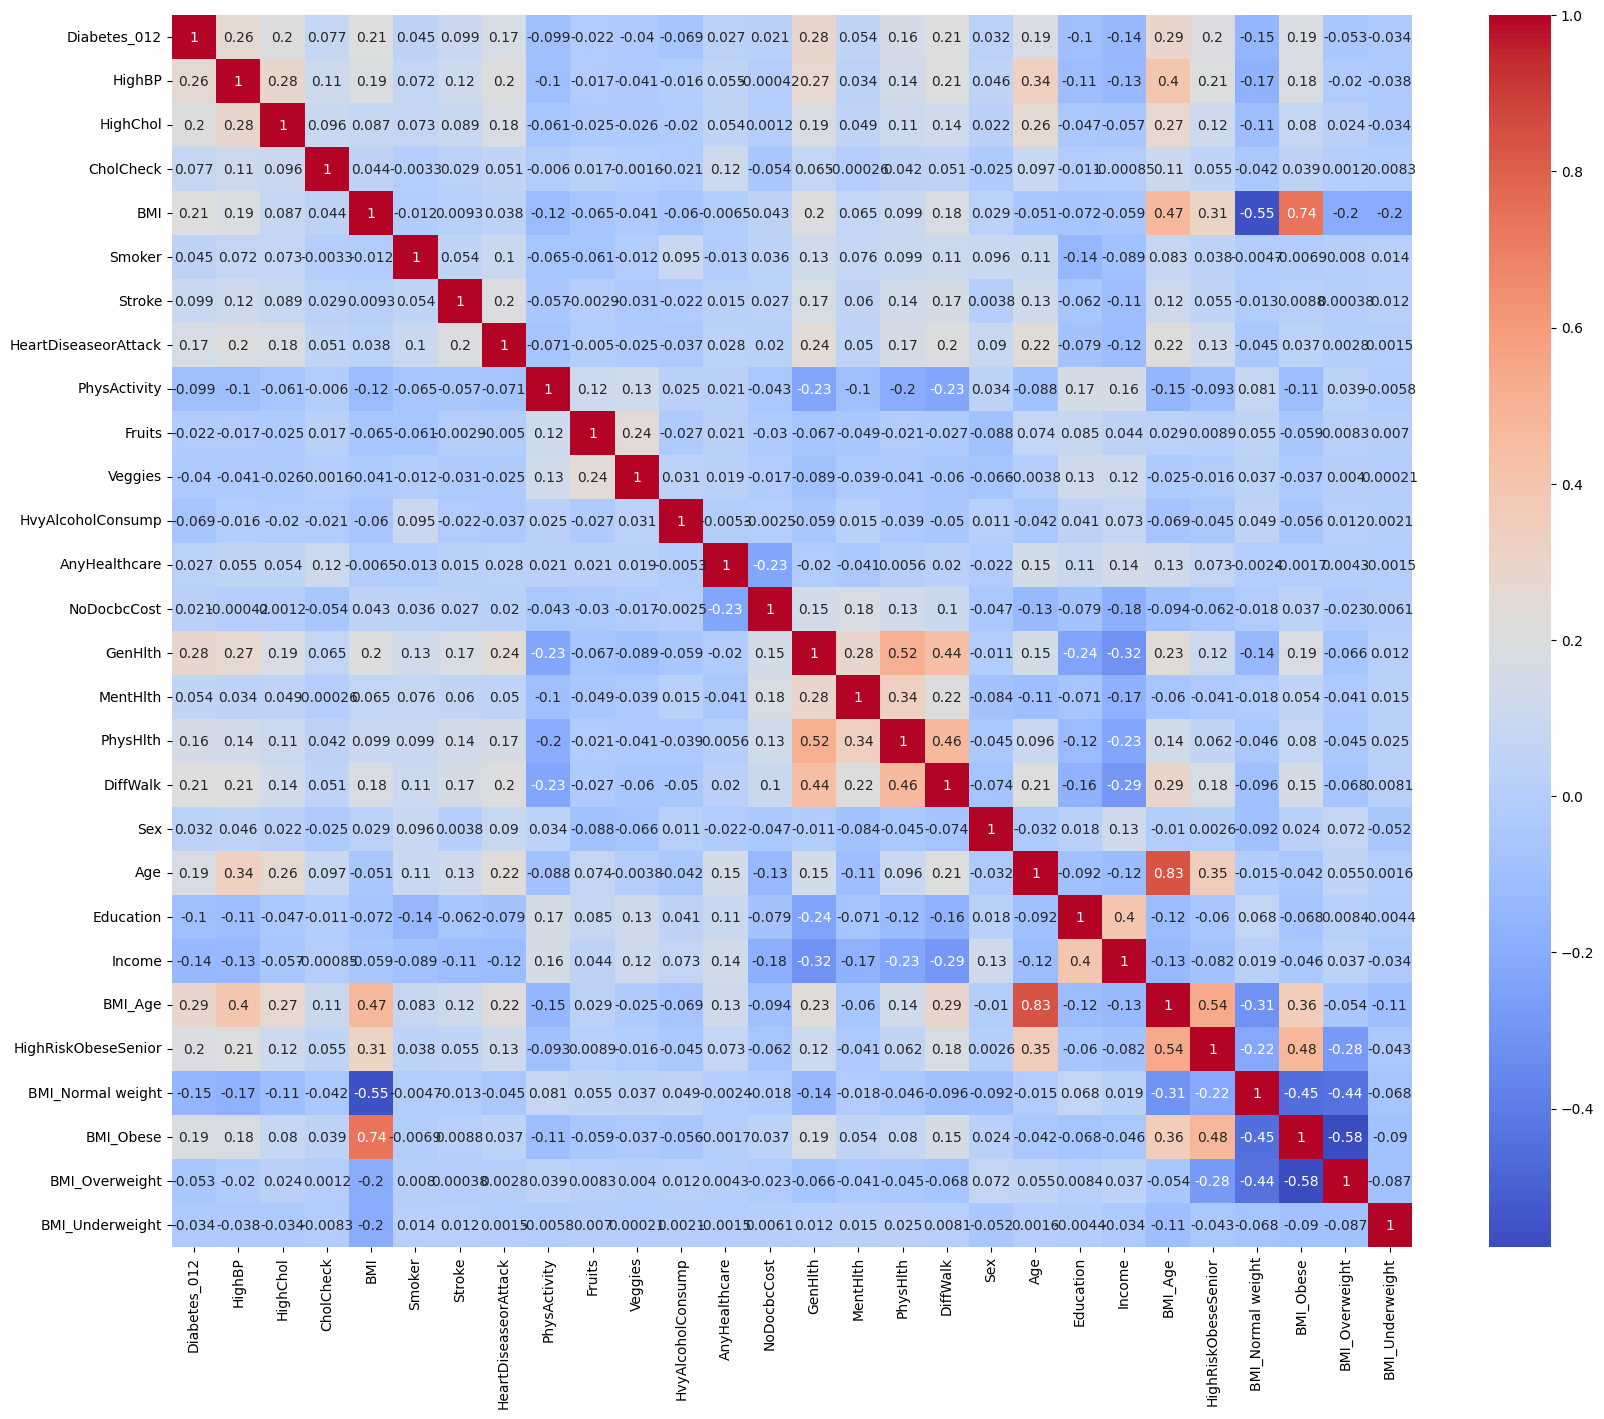

In [24]:
# Correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(df_dummies.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Insights:
* Diabetes appears to be most correlated to high blood pressure, the patient's general health rating, and the product between age and BMI

#### Multivariate Analysis

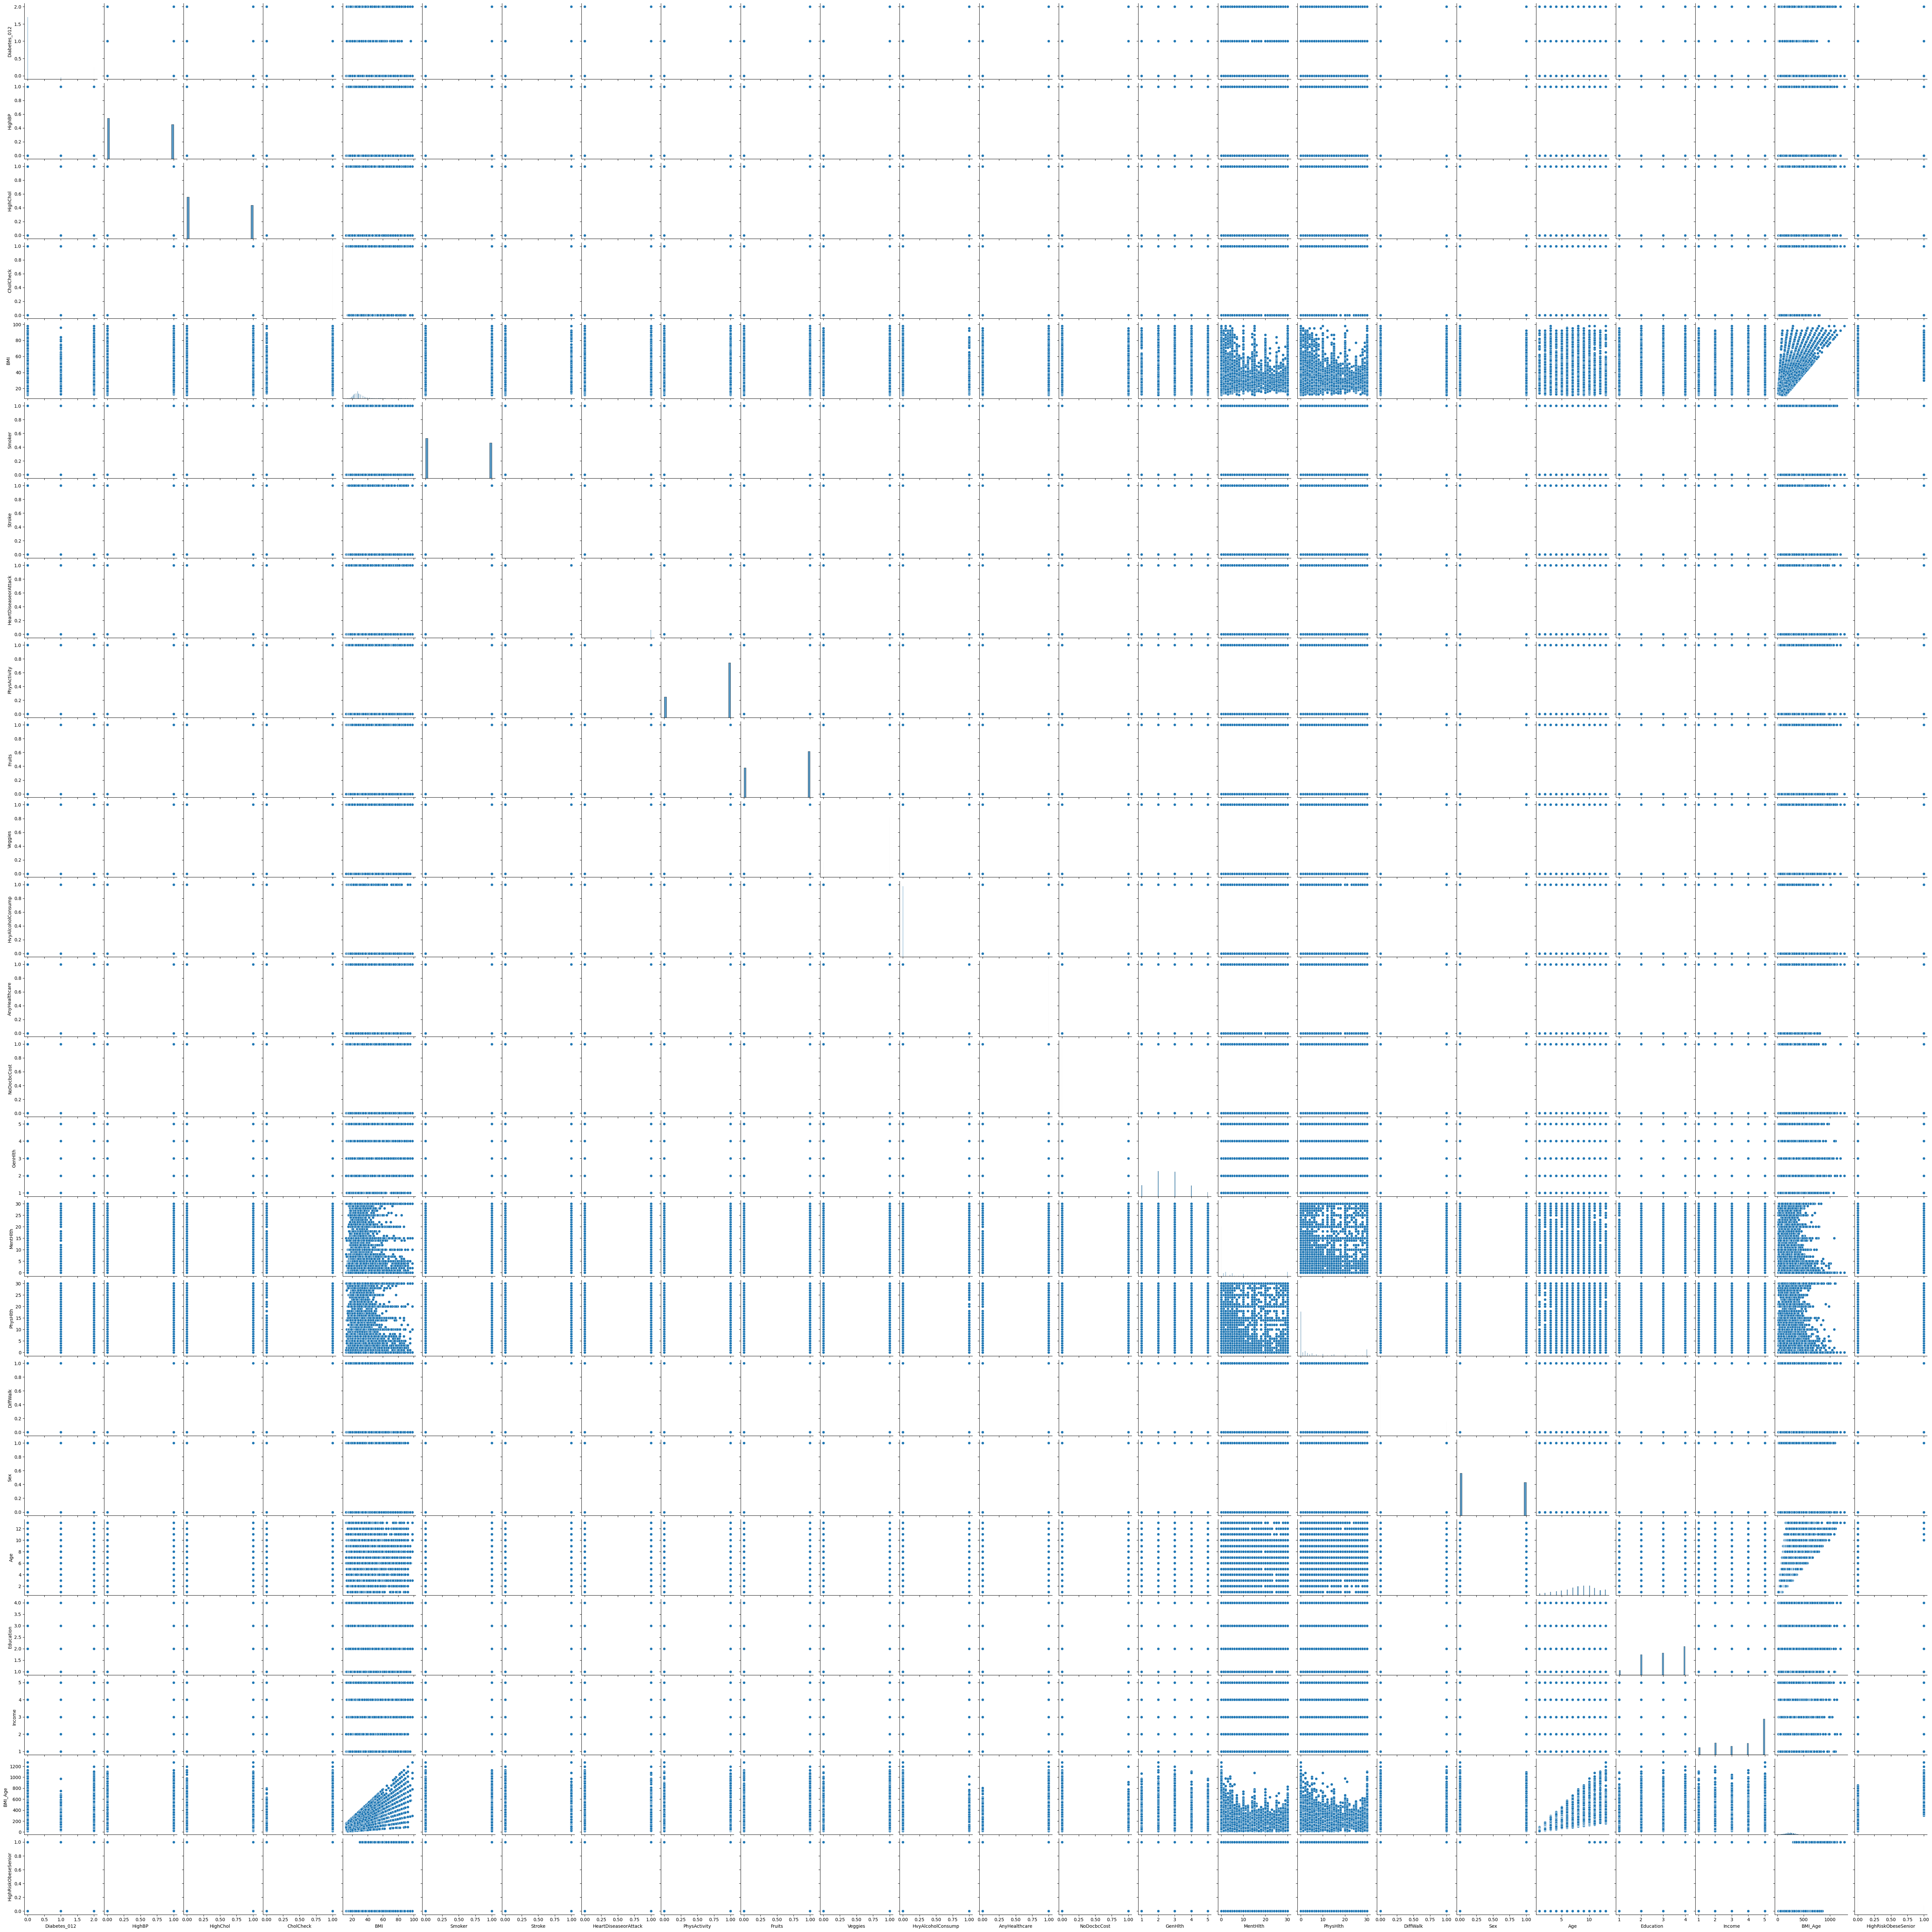

In [25]:
# Pair plot
sns.pairplot(df)
plt.show()